 MLP (Multi-Layer Perceptron)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")
print(f"Layers: {model.config.n_layer}")

# MLP structure dekho
layer0_mlp = model.h[0].mlp
print(f"\nMLP structure:")
print(f"  Input:  {model.config.n_embd}")
print(f"  Hidden: {layer0_mlp.c_fc.weight.shape}")
print(f"  Output: {layer0_mlp.c_proj.weight.shape}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3674.23it/s]

Ready!
Layers: 12

MLP structure:
  Input:  768
  Hidden: torch.Size([768, 3072])
  Output: torch.Size([3072, 768])


In [2]:
fc_means, fc_stds   = [], []
proj_means, proj_stds = [], []

for layer_idx in range(12):
    mlp = model.h[layer_idx].mlp
    
    fc_w   = mlp.c_fc.weight    # [768, 3072]
    proj_w = mlp.c_proj.weight  # [3072, 768]
    
    fc_means.append(fc_w.mean().item())
    fc_stds.append(fc_w.std().item())
    proj_means.append(proj_w.mean().item())
    proj_stds.append(proj_w.std().item())

print(f"{'Layer':<8} {'FC mean':<10} {'FC std':<10} {'Proj mean':<12} {'Proj std'}")
print("-"*52)
for i in range(12):
    print(f"L{i+1:<7} {fc_means[i]:<10.4f} {fc_stds[i]:<10.4f} "
          f"{proj_means[i]:<12.4f} {proj_stds[i]:.4f}")

Layer    FC mean    FC std     Proj mean    Proj std
----------------------------------------------------
L1       -0.0007    0.1412     0.0000       0.0880
L2       0.0006     0.1307     0.0001       0.0872
L3       -0.0051    0.1335     0.0002       0.0931
L4       -0.0060    0.1295     0.0002       0.0918
L5       -0.0033    0.1297     0.0002       0.0910
L6       -0.0042    0.1267     0.0001       0.0974
L7       -0.0028    0.1264     0.0001       0.1073
L8       -0.0035    0.1264     0.0001       0.1187
L9       -0.0021    0.1273     0.0000       0.1354
L10      -0.0027    0.1276     0.0000       0.1559
L11      -0.0032    0.1276     0.0000       0.1781
L12      -0.0018    0.1300     -0.0004      0.1982


In [3]:
text = "The king and queen ruled the kingdom"
inputs = tokenizer(text, return_tensors="pt")


mlp_activations = {}

def make_hook(layer_idx):
    def hook(module, input, output):
        mlp_activations[layer_idx] = output.detach()
    return hook

hooks = []
for i in range(12):
    h = model.h[i].mlp.register_forward_hook(make_hook(i))
    hooks.append(h)

with torch.no_grad():
    outputs = model(**inputs)

for h in hooks:
    h.remove()

# Stats
print(f"{'Layer':<8} {'Mean':<10} {'Std':<10} {'Max':<10} {'Min'}")
print("-"*48)
for i in range(12):
    act = mlp_activations[i][0]
    print(f"L{i+1:<7} {act.mean():.4f}     "
          f"{act.std():.4f}     "
          f"{act.max():.4f}     "
          f"{act.min():.4f}")

Layer    Mean       Std        Max        Min
------------------------------------------------
L1       0.0198     2.0302     95.1319     -66.8175
L2       0.1079     6.7460     486.4777     -5.6254
L3       0.4445     31.6280     2317.2539     -1.8698
L4       0.0485     2.6110     175.4489     -2.0731
L5       0.0400     2.1354     147.8417     -2.7905
L6       0.0305     1.4690     98.9544     -3.1378
L7       0.0233     1.0384     57.8983     -2.7128
L8       0.0275     0.9847     34.9077     -6.3700
L9       0.0210     0.9931     20.2648     -9.7984
L10      0.0140     1.1871     18.4334     -16.8421
L11      0.1153     3.6686     67.8189     -69.8847
L12      -0.0466     3.9981     56.3203     -116.9493


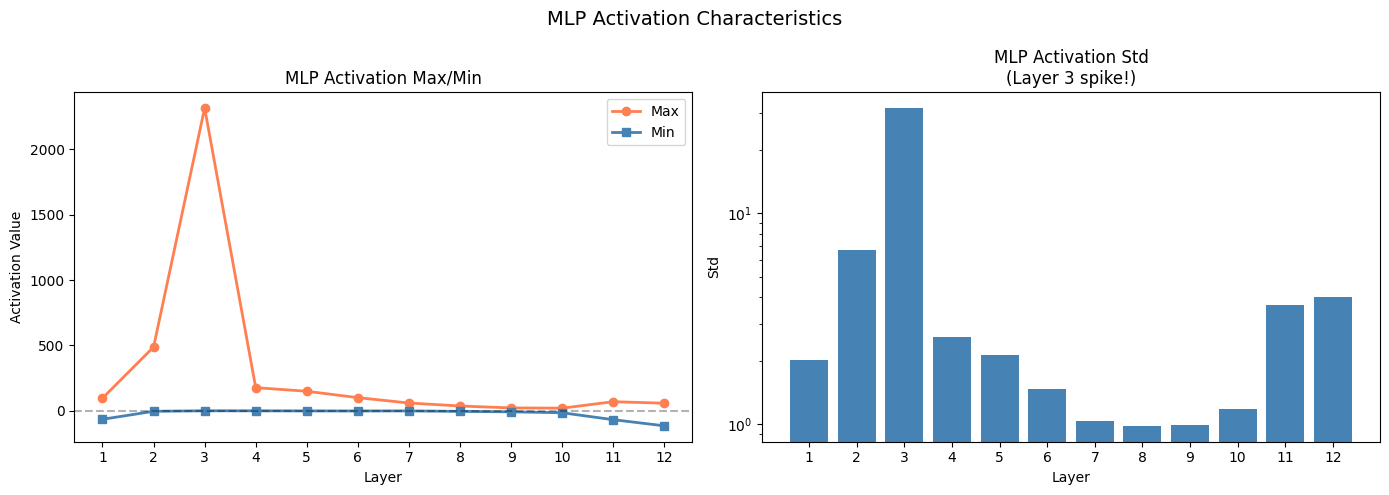

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

layers = range(1, 13)
maxes  = [mlp_activations[i][0].max().item() for i in range(12)]
mins   = [mlp_activations[i][0].min().item() for i in range(12)]
stds   = [mlp_activations[i][0].std().item() for i in range(12)]

# Max/Min
axes[0].plot(layers, maxes, marker='o', 
             color="coral", label="Max", linewidth=2)
axes[0].plot(layers, mins, marker='s',
             color="steelblue", label="Min", linewidth=2)
axes[0].axhline(y=0, color="black", 
                linestyle="--", alpha=0.3)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Activation Value")
axes[0].set_title("MLP Activation Max/Min")
axes[0].legend()
axes[0].set_xticks(layers)

# Std
axes[1].bar(layers, stds, color="steelblue")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Std")
axes[1].set_title("MLP Activation Std\n(Layer 3 spike!)")
axes[1].set_xticks(layers)
axes[1].set_yscale("log")

plt.suptitle("MLP Activation Characteristics", fontsize=14)
plt.tight_layout()
plt.show()


* Fully Connected (FC) weights are stable across all layers.
* Projection weights become more expressive in deeper layers.
* Activation explosion is observed in Layer 3 (value: 2317!), which matches the behavior seen in Project 28.
* GELU suppresses negative values.
